# Lineare Regression: Einkommen vorhersagen (`ConvertedCompTotal`)

In diesem Skript wurde ein naives Modell entwickelt, dass nur basiered auf den Spalte `Country` sowie `WorkExp` versucht `ConvertedCompTotal` vorherzusagen



In [11]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold


## Laden des Datensatzes und Definition des naiven Feature-Sets

In dieser Zelle wird der bereits One-Hot-encodierte Datensatz geladen und gezielt für ein naives Regressionsmodell vorbereitet.

Zunächst wird die Zielvariable `ConvertedCompTotal` bereinigt:
- Extreme Ausreißer werden oberhalb des 98-Perzentils entfernt, um eine starke Verzerrung der Regression zu vermeiden.
- Zusätzlich werden sehr niedrige Einkommen (≤ 10.000) ausgeschlossen, um unrealistische oder nicht vergleichbare Beobachtungen zu entfernen.
Die deskriptive Statistik der bereinigten Zielvariable wird zur Plausibilisierung ausgegeben.

Anschließend werden boolesche Spalten in Integer-Werte umgewandelt, sodass alle Features numerisch vorliegen.

Für das naive Modell werden bewusst nur sehr wenige erklärende Variablen verwendet:
- `WorkExp` als einfacher, kontinuierlicher Erfahrungsindikator
- One-Hot-encodierte Länderinformationen (`Country_*`) als grobe strukturelle Variable

Alle übrigen Merkmale werden verworfen.  
Diese starke Feature-Reduktion dient dazu, ein bewusst einfaches Referenzmodell zu erstellen, das als Vergleichsbasis für ein komplexes Regressionsmodell fungiert.


In [12]:

df = pd.read_csv("../One-Hot-Encoded.csv")


q98 = df["ConvertedCompTotal"].dropna().quantile(0.98)
df = df[df["ConvertedCompTotal"] <= q98].copy()
print(df["ConvertedCompTotal"].describe())

df = df[df["ConvertedCompTotal"] > 10000].copy()

bool_cols = df.select_dtypes(include=['bool']).columns

for col in bool_cols:
    df[col] = df[col].astype(int)
df.dtypes

# Droppe alles außer WorkExp und alle Country One-Hot-Encoding Spalten
country_cols = [col for col in df.columns if col.startswith("Country_")]
cols_to_keep = ["WorkExp"] + country_cols + ["ConvertedCompTotal"]
df = df[cols_to_keep].copy()

count     21785.000000
mean      86982.492836
std       63772.008524
min           0.000000
25%       40873.000000
50%       75924.190383
75%      120000.000000
max      331000.000000
Name: ConvertedCompTotal, dtype: float64


## Definition von Features und Zielvariable

In dieser Zelle wird die Feature-Matrix sowie die Zielvariable für das naive Regressionsmodell final definiert.

Die Zielvariable wird explizit als `ConvertedCompTotal` festgelegt.  
Als erklärende Variablen werden alle numerischen Spalten verwendet, mit Ausnahme der Zielvariable selbst. Dies umfasst in diesem Modell ausschließlich:
- `WorkExp`
- die One-Hot-encodierten Länderindikatoren (`Country_*`)

Anschließend wird ein konsistentes Entfernen fehlender Werte durchgeführt. Es werden nur diejenigen Beobachtungen beibehalten, bei denen sowohl alle Feature-Werte als auch der Zielwert vorhanden sind. Dadurch wird sichergestellt, dass das Regressionsmodell auf einer vollständigen und konsistenten Datenbasis trainiert wird.

Zum Abschluss werden die Dimensionen der Feature-Matrix und der Zielvariable ausgegeben sowie eine deskriptive Statistik der Zielvariable zur Plausibilisierung angezeigt.


In [ ]:
TARGET = "ConvertedCompTotal"

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
feature_cols = [c for c in num_cols if c != TARGET]

X = df[feature_cols].copy()
y = df[TARGET].copy()


# Konsistentes Dropna (Check, dass X vollständig + y vorhanden)
mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].copy()

print("After dropna -> X:", X.shape, "y:", y.shape)
y.describe()

After dropna -> X: (19232, 176) y: (19232,)


count     19232.000000
mean      97683.383702
std       59974.719327
min       10000.000000
25%       53722.829212
50%       85000.000000
75%      128458.000000
max      331000.000000
Name: ConvertedCompTotal, dtype: float64

In [14]:
y_model = y.astype(float)
y_model.head()

0     61659.84
1    105102.00
3     36435.36
4     60000.00
5    120000.00
Name: ConvertedCompTotal, dtype: float64

## Aufteilung in Trainings- und Testdaten

In dieser Zelle wird der Datensatz in Trainings- und Testdaten aufgeteilt.

Die Feature-Matrix und die Zielvariable werden in einen Trainingsanteil (80 %) und einen Testanteil (20 %) getrennt.  
Die Trainingsdaten werden ausschließlich für das Lernen der Modellparameter verwendet, während die Testdaten für die spätere, unabhängige Bewertung der Modellleistung reserviert bleiben.

Durch die Festlegung eines festen `random_state` wird sichergestellt, dass die Aufteilung reproduzierbar ist.
Diese Trennung ist insbesondere für die Bewertung der Prädiktionsleistung des naiven Modells notwendig.


In [15]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_model,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (15385, 176) Test: (3847, 176)


## Vorverarbeitung für das naive Regressionsmodell

In dieser Zelle wird die Vorverarbeitung der Features für das naive Regressionsmodell definiert.

Als numerisches Merkmal wird ausschließlich `WorkExp` verwendet. Dieses Feature wird mithilfe eines `StandardScaler` standardisiert, um eine vergleichbare Skala für die Regression sicherzustellen.

Alle übrigen Features bestehen aus One-Hot-encodierten Länderindikatoren und werden unverändert an das Modell weitergegeben (`passthrough`), da sie bereits binär kodiert sind.

Die Vorverarbeitung wird mit einem `ColumnTransformer` umgesetzt und explizit auf das reduzierte Feature-Set zugeschnitten.  
Nicht definierte Spalten werden verworfen, wodurch sichergestellt wird, dass das Modell ausschließlich auf den bewusst ausgewählten, naiven Prädiktoren basiert.


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

num_cols = ["WorkExp"]
dummy_cols = [c for c in X.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("dum", "passthrough", dummy_cols),
    ],
    remainder="drop"
)


## Modelltraining und -auswahl für das naive Regressionsmodell

In dieser Zelle wird das eigentliche Regressionsmodell für das naive Feature-Set trainiert und optimiert.

Zunächst wird eine Pipeline definiert, die aus zwei Schritten besteht:
- der zuvor festgelegten Vorverarbeitung (`preprocess`) für `WorkExp` und die Länder-Dummies
- einem linearen Regressionsmodell mit Regularisierung, das zunächst als Platzhalter (`Ridge`) eingesetzt wird

Im Anschluss wird ein Parametergrid definiert, das drei regularisierte lineare Modelle umfasst:
- Ridge Regression (L2-Regularisierung)
- Lasso Regression (L1-Regularisierung)
- ElasticNet, das beide Regularisierungsarten kombiniert

Für jedes Modell werden verschiedene Werte der Regularisierungsstärke (`alpha`) und – im Fall von ElasticNet – unterschiedliche Mischungsverhältnisse (`l1_ratio`) getestet.

Die Modell- und Hyperparameter-Auswahl erfolgt mittels `GridSearchCV` auf den Trainingsdaten:
- Als Optimierungskriterium dient der Root Mean Squared Error (RMSE), der minimiert wird.
- Die Bewertung erfolgt über Cross-Validation, um eine robuste Schätzung der Modellleistung zu erhalten.
- Das jeweils beste Modell wird automatisch erneut auf den gesamten Trainingsdaten trainiert (`refit=True`).

Nach Abschluss der Grid Search werden das beste Modell, die optimalen Hyperparameter sowie der zugehörige Cross-Validation-RMSE ausgegeben.
Das resultierende Pipeline-Modell wird für die nachfolgenden Analysen und die Prädiktion auf den Testdaten gespeichert.


In [ ]:
# Grid Search (Ridge / Lasso / ElasticNet) mit Preprocessing-Pipeline

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge())  # dient als Platzhalter für die Pipeline. Wird später durch bestes Modell erstetzt
])

param_grid = [
    {
        "model": [Ridge()],
        "model__alpha": [0.01, 0.1, 1, 10, 100, 300, 1000]
    },
    {
        "model": [Lasso(max_iter=20000)],
        "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]
    },
    {
        "model": [ElasticNet(max_iter=20000)],
        "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    }
]


grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",  # RMSE minimieren
    cv=3,
    n_jobs=-1,
    refit=True
)

grid.fit(X_train, y_train)

print("Bestes Modell:", grid.best_estimator_.named_steps["model"])
print("Beste Parameter:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

best_pipe = grid.best_estimator_
clf = best_pipe.named_steps["model"]


/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.948e+12, tolerance: 3.689e+09
  model = cd_fast.enet_coordinate_descent(
/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.948e+12, tolerance: 3.689e+09
  model = cd_fast.enet_coordinate_descent(
/Users/jonas/Documents/DataAnalytics/Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

Bestes Modell: ElasticNet(alpha=0.001, l1_ratio=0.3, max_iter=20000)
Beste Parameter: {'model': ElasticNet(max_iter=20000), 'model__alpha': 0.001, 'model__l1_ratio': 0.3}
Best CV RMSE: 45934.644674314644


## Prädiktion und Evaluation des naiven Regressionsmodells

In dieser Zelle wird das zuvor mittels Grid Search ausgewählte beste naive Regressionsmodell auf die Testdaten angewandt.

Zunächst werden die Vorhersagen für die Test-Feature-Matrix erzeugt und den tatsächlichen Zielwerten gegenübergestellt.
Als Referenz wird zusätzlich eine einfache Baseline berechnet, bei der für alle Testbeobachtungen der Mittelwert der Zielvariable aus den Trainingsdaten vorhergesagt wird.

Die Modellleistung wird anschließend anhand mehrerer etablierter Evaluationsmaße bewertet:
- RMSE (Root Mean Squared Error) zur Beurteilung der durchschnittlichen quadratischen Abweichung
- R² zur Einschätzung des erklärten Varianzanteils
- MAE (Mean Absolute Error) als robustes Maß für den mittleren absoluten Fehler

Der Vergleich mit der Mittelwert-Baseline ermöglicht eine Einordnung der Leistungsfähigkeit des naiven Modells und zeigt, inwieweit bereits die sehr einfache Feature-Auswahl (`WorkExp` und `Country`) erklärende und prädiktive Information liefert.
Diese Evaluation erfolgt ausschließlich auf den Testdaten und stellt somit eine unverzerrte Bewertung der Prädiktionsleistung dar.


In [ ]:
# Prediktion mit bestem Modell aus Grid Search

predicted = best_pipe.predict(X_test)
expected = y_test

# Mittelwertsbaseline mit ausgeben für Modellevaluation
test_predict_mean = np.full(len(y_test), y_train.mean())
print("Baseline Mean RMSE:")
rmse_baseline = np.sqrt(mean_squared_error(expected, test_predict_mean))
print(rmse_baseline)

print("RMSE:")
rmse = np.sqrt(mean_squared_error(expected, predicted))
print(rmse)

print("R^2:")
r2 = r2_score(expected, predicted)
print(r2)

print("MAE:")
mae = mean_absolute_error(expected, predicted)
print(mae)


Baseline Mean RMSE:
58820.38297676608
RMSE:
45271.42141858849
R^2:
0.407431957293621
MAE:
32563.900260535615


## Übersicht der besten Cross-Validation-Ergebnisse

In dieser optionalen Zelle werden die Ergebnisse der Grid Search aus der Cross-Validation detailliert ausgewertet.

Die vollständigen Cross-Validation-Ergebnisse (`cv_results_`) werden in ein DataFrame überführt und auf die relevantesten Informationen reduziert:
- Rang des Modells innerhalb der Grid Search
- Mittlerer Validierungsfehler
- Streuung der Validierungsergebnisse
- Zugehörige Hyperparameter-Kombinationen

Da in der Grid Search das negative RMSE als Optimierungskriterium verwendet wurde, wird der Wert wieder in ein positives RMSE zurückgerechnet, um die Interpretation zu erleichtern.

Die Tabelle zeigt die besten Modellkonfigurationen nach RMSE sortiert und ermöglicht einen transparenten Vergleich der getesteten Regularisierungsansätze und Hyperparameter.
Diese Auswertung unterstützt die Nachvollziehbarkeit der Modellselektion.


In [ ]:
# Top-Ergebnisse aus der GridSearch nach RMSE sortiert

cv_res = pd.DataFrame(grid.cv_results_)
cols_show = ["rank_test_score", "mean_test_score", "std_test_score", "params"]
cv_res_sorted = cv_res[cols_show].sort_values("rank_test_score").head(10)

# RMSE aus neg_root_mean_squared_error zurückrechnen
cv_res_sorted = cv_res_sorted.assign(
    mean_RMSE = -cv_res_sorted["mean_test_score"],
    std_RMSE = cv_res_sorted["std_test_score"]
).drop(columns=["mean_test_score", "std_test_score"])

cv_res_sorted


,rank_test_score,params,mean_RMSE,std_RMSE
19,1,"{'model': ElasticNet(max_iter=20000), 'model__...",45934.644674,405.023458
20,2,"{'model': ElasticNet(max_iter=20000), 'model__...",45934.704655,406.225393
18,3,"{'model': ElasticNet(max_iter=20000), 'model__...",45939.215716,405.865047
3,4,"{'model': Ridge(), 'model__alpha': 10}",45941.649390,406.450471
27,5,"{'model': ElasticNet(max_iter=20000), 'model__...",45942.535928,406.668342
21,6,"{'model': ElasticNet(max_iter=20000), 'model__...",45945.455878,412.688667
12,7,"{'model': Lasso(max_iter=20000), 'model__alpha...",45973.970833,434.843780
22,8,"{'model': ElasticNet(max_iter=20000), 'model__...",45999.193420,441.105432
2,9,"{'model': Ridge(), 'model__alpha': 1}",46000.777539,441.934720
13,10,"{'model': ElasticNet(max_iter=20000), 'model__...",46005.785601,444.576671


## Vergleich von tatsächlichen und vorhergesagten Zielwerten

In dieser Zelle wird die Vorhersagequalität des Modells grafisch beurteilt.
Dazu werden die tatsächlichen Zielwerte den vorhergesagten Werten in einem Streudiagramm gegenübergestellt.

Die rote Diagonale repräsentiert die ideale Vorhersage, bei der tatsächlicher und vorhergesagter Wert übereinstimmen.
Punkte nahe dieser Linie deuten auf eine gute Modellanpassung hin, während systematische Abweichungen auf Bias oder Heteroskedastizität hinweisen können.

Diese Visualisierung ergänzt die numerischen Evaluationsmaße und erlaubt eine intuitive Einschätzung der Prädiktionsgüte über den gesamten Wertebereich der Zielvariable hinweg.


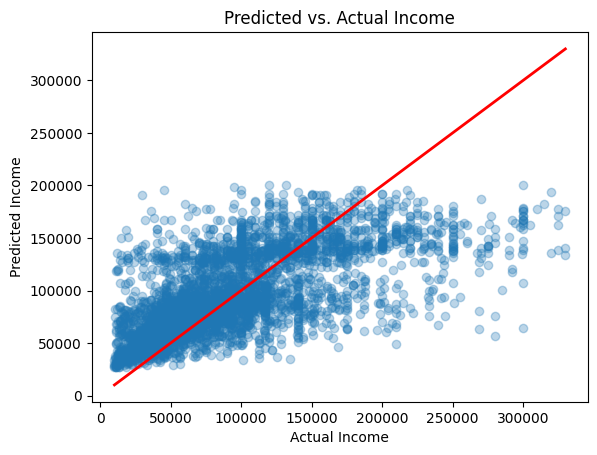

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(expected, predicted, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2
)
plt.xlabel("Actual Income")
plt.ylabel("Predicted Income")
plt.title("Predicted vs. Actual Income")
plt.show()



## Residuenanalyse zur Modellvalidierung

In dieser Zelle werden die Residuen des Regressionsmodells analysiert.
Die Residuen ergeben sich als Differenz zwischen den tatsächlichen und den vorhergesagten Zielwerten.

Im Streudiagramm werden die Residuen in Abhängigkeit von den vorhergesagten Werten dargestellt.
Die horizontale Linie bei Null kennzeichnet eine fehlerfreie Vorhersage.

Eine zufällige Streuung der Punkte um die Nulllinie spricht für ein gut angepasstes Modell.
Systematische Muster oder eine fächerförmige Struktur können hingegen auf Modellverletzungen wie Nichtlinearität oder Heteroskedastizität hinweisen.

Diese Residuenanalyse dient der qualitativen Überprüfung der Modellannahmen der linearen Regression.


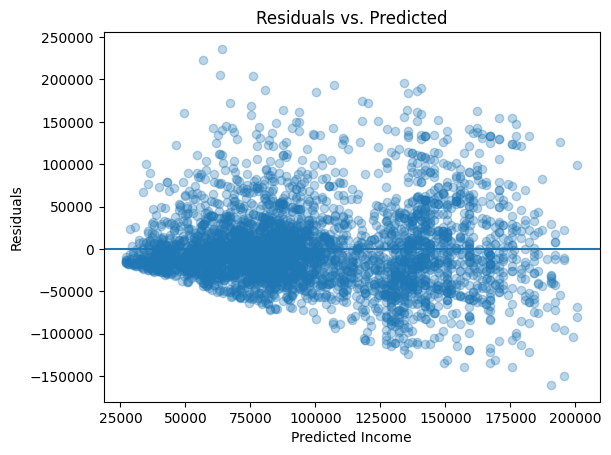

In [21]:
residuals = expected - predicted

plt.figure()
plt.scatter(predicted, residuals, alpha=0.3)
plt.axhline(0)
plt.xlabel("Predicted Income")
plt.ylabel("Residuals")
plt.title("Residuals vs. Predicted")
plt.show()


## Vergleich der Verteilungen von tatsächlichen und vorhergesagten Werten

In dieser Zelle werden die Verteilungen der tatsächlichen Zielwerte und der vom Modell vorhergesagten Werte gegenübergestellt.
Beide Verteilungen werden in einem Histogramm visualisiert, um Unterschiede in Lage, Streuung und Form zu erkennen.

Ein ähnlicher Verlauf der beiden Verteilungen deutet darauf hin, dass das Modell die grundlegende Struktur der Zielvariable gut erfasst.
Abweichungen können auf systematische Über- oder Unterschätzungen in bestimmten Wertebereichen hinweisen.

Diese Analyse ergänzt die Punkt- und Residuenplots und unterstützt die Gesamtbewertung der Prädiktionsqualität des Modells.


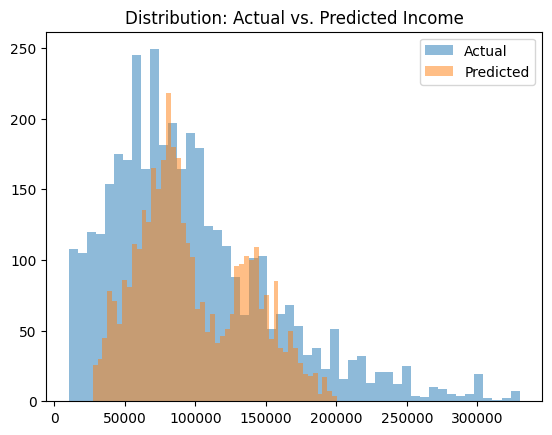

In [22]:
plt.figure()
plt.hist(expected, bins=50, alpha=0.5, label="Actual")
plt.hist(predicted, bins=50, alpha=0.5, label="Predicted")
plt.legend()
plt.title("Distribution: Actual vs. Predicted Income")
plt.show()


In [ ]:
print("Intercept:", clf.intercept_)

feature_names = num_cols + dummy_cols

coeff_df = pd.DataFrame({"Feature": feature_names, "Coefficient": clf.coef_})
print("\nFeature Coefficients:\n", coeff_df)


Intercept: 76028.65935045197

Feature Coefficients:
                  Feature   Coefficient
0                WorkExp  15649.566894
1    Country_Afghanistan      0.000000
2        Country_Albania  -3958.123790
3        Country_Algeria  -7691.486498
4        Country_Andorra  -4333.567461
..                   ...           ...
171     Country_Viet Nam  -2752.363457
172        Country_Yemen  -3459.666900
173       Country_Zambia  -2639.372834
174     Country_Zimbabwe  -4393.385589
175          Country_nan      0.000000

[176 rows x 2 columns]


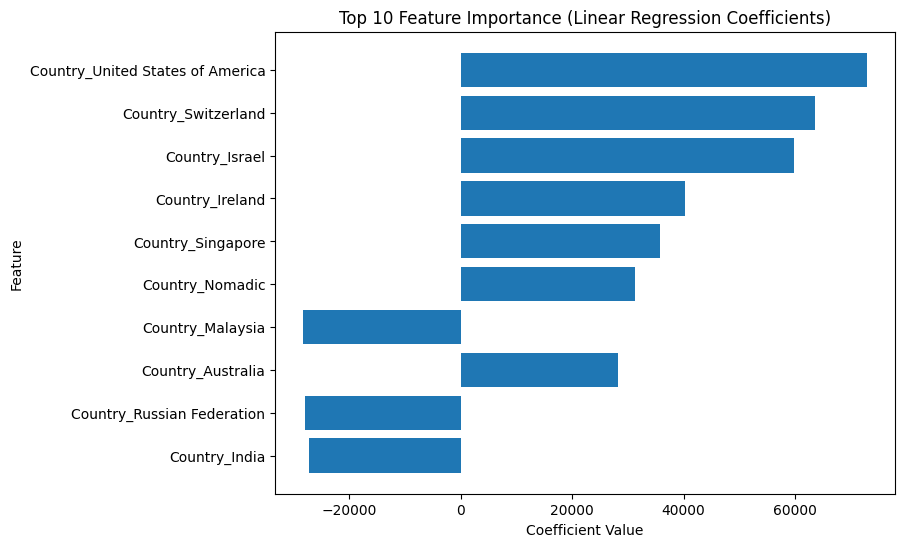

In [24]:
# Sort by absolute coefficient value and take top 10
coef_df_sorted = (
    coeff_df
    .assign(abs_coef=coeff_df["Coefficient"].abs())
    .sort_values(by="abs_coef", ascending=False)
    .head(10)
)

# Plot
plt.figure(figsize=(8, 6))
plt.barh(coef_df_sorted["Feature"], coef_df_sorted["Coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance (Linear Regression Coefficients)")
plt.gca().invert_yaxis()  # highest importance on top
plt.show()


## Erweiterte Residuen- und Fit-Analyse

In dieser Zelle werden zwei ergänzende Visualisierungen zur Bewertung des Regressionsmodells erstellt.

Im ersten Plot wird die Verteilung der Residuen dargestellt.  
Die Residuen ergeben sich als Differenz zwischen tatsächlichen und vorhergesagten Werten. Eine symmetrische Verteilung um Null spricht für ein unverzerrtes Modell, während Schiefe oder Mehrgipfligkeit auf systematische Fehler hinweisen können. Die eingezeichnete Nulllinie dient als Referenz.

Der zweite Plot zeigt den Regression Fit in Form eines Streudiagramms der tatsächlichen gegen die vorhergesagten Werte.  
Die gestrichelte Diagonale repräsentiert die ideale Vorhersage. Je näher die Punkte an dieser Linie liegen, desto besser ist die Anpassung des Modells.

Diese beiden Visualisierungen ergänzen die numerischen Evaluationsmaße und ermöglichen eine visuelle Beurteilung von Fehlerstruktur und Vorhersagequalität.


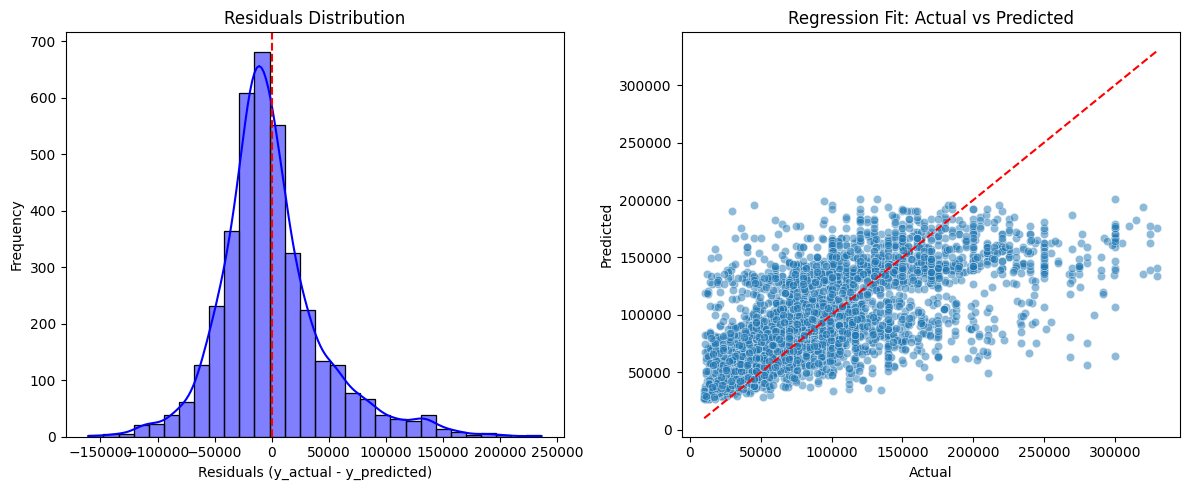

In [ ]:

residuals = expected - predicted


plt.figure(figsize=(12,5))

# Residuals Verteilung
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")


# Regression Fit
plt.subplot(1,2,2)
sns.scatterplot(x=expected, y=predicted, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Perfect fit line
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")


plt.tight_layout()
plt.show()

## Fazit zum naiven Regressionsmodell

Das naive Regressionsmodell, das ausschließlich auf WorkExp und der Länderzugehörigkeit (Country) basiert, dient als einfache Referenz zur Einordnung komplexerer Modelle.

Die Evaluation auf den Testdaten zeigt, dass das Modell einen klaren Mehrwert gegenüber einer trivialen Mittelwertvorhersage liefert:
Der RMSE konnte von 58 820 (Baseline) auf 45 271 reduziert werden, was auf eine relevante Verbesserung der Vorhersagegenauigkeit hinweist.

Mit einem R²-Wert von 0,41 erklärt das Modell rund 40 % der Varianz der Zielvariable. Dies zeigt, dass bereits sehr einfache strukturelle Informationen, hier Berufserfahrung und Länderunterschiede, einen substantiellen Einfluss auf das Einkommen haben.

Im direkten Vergleich mit dem erweiterten Regressionsmodell wird jedoch die Limitation des naiven Ansatzes deutlich:
Das komplexere Modell erreicht einen R²-Wert von 0,59 und kann damit rund 60 % der Varianz erklären, bei gleichzeitig niedrigerem RMSE von 38 341.  
Dies entspricht sowohl einer höheren Erklärungsleistung als auch einer deutlich verbesserten Vorhersagegenauigkeit.

Der weiterhin vergleichsweise hohe RMSE sowie der MAE von 32 564 im naiven Modell verdeutlichen, dass ein erheblicher Teil der Varianz unberücksichtigt bleibt. Dies ist erwartbar, da viele relevante Einflussfaktoren (z. B. Ausbildung, Rolle, Branche oder Arbeitszeitmodell) bewusst nicht berücksichtigt wurden.

Insgesamt erfüllt das naive Modell seinen Zweck als Baseline-Modell:  
Es liefert eine nachvollziehbare, interpretierbare und methodisch saubere Referenz und macht zugleich deutlich, welchen Mehrwert ein erweitertes Feature-Set für Modellierung und Prädiktion bietet.
Damit bildet es eine geeignete Ausgangsbasis für den Vergleich mit komplexeren Regressionsmodellen.
